<a href="https://colab.research.google.com/github/preethamreddy2906-collab/Video_action_recognition/blob/main/Action_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
import torch
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import random
np.random.seed(42)
from torch.utils.data import TensorDataset,DataLoader
from torch._prims_common import Tensor
from cv2.gapi import resize
from collections import deque
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
import seaborn as sns
import time

In [ ]:
path = kagglehub.dataset_download("matthewjansen/ucf101-action-recognition")

print("Path to dataset files:", path)

100%|██████████| 6.53G/6.53G [01:02<00:00, 112MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/matthewjansen/ucf101-action-recognition/versions/4


In [ ]:
os.listdir(path)

['val.csv', 'test.csv', 'train', 'val', 'train.csv', 'test']

In [ ]:
contents=os.path.join(path,'train')

In [ ]:
len(contents)

88

In [ ]:
classes=os.listdir(contents)
total_num_classes=len(classes)
total_num_classes

101

In [ ]:
np.random.seed(42)
mask=np.random.choice(total_num_classes,10,replace=False)
mask

array([84, 55, 66, 67, 45, 39, 22, 44, 10,  0])

In [ ]:
selected_classes=[classes[i] for i in mask]
selected_classes

['IceDancing',
 'SalsaSpin',
 'BreastStroke',
 'MilitaryParade',
 'FloorGymnastics',
 'BasketballDunk',
 'UnevenBars',
 'Kayaking',
 'SkateBoarding',
 'CuttingInKitchen']

In [ ]:
content2=os.path.join(contents,'HorseRace')

In [ ]:
os.listdir(content2)

['v_HorseRace_g13_c02.avi',
 'v_HorseRace_g12_c04.avi',
 'v_HorseRace_g06_c06.avi',
 'v_HorseRace_g13_c05.avi',
 'v_HorseRace_g11_c03.avi',
 'v_HorseRace_g24_c01.avi',
 'v_HorseRace_g17_c02.avi',
 'v_HorseRace_g05_c04.avi',
 'v_HorseRace_g16_c03.avi',
 'v_HorseRace_g07_c04.avi',
 'v_HorseRace_g04_c04.avi',
 'v_HorseRace_g11_c04.avi',
 'v_HorseRace_g18_c01.avi',
 'v_HorseRace_g13_c03.avi',
 'v_HorseRace_g15_c02.avi',
 'v_HorseRace_g14_c01.avi',
 'v_HorseRace_g22_c04.avi',
 'v_HorseRace_g24_c04.avi',
 'v_HorseRace_g05_c03.avi',
 'v_HorseRace_g22_c03.avi',
 'v_HorseRace_g18_c02.avi',
 'v_HorseRace_g07_c03.avi',
 'v_HorseRace_g24_c06.avi',
 'v_HorseRace_g05_c02.avi',
 'v_HorseRace_g04_c02.avi',
 'v_HorseRace_g05_c01.avi',
 'v_HorseRace_g12_c03.avi',
 'v_HorseRace_g13_c04.avi',
 'v_HorseRace_g03_c04.avi',
 'v_HorseRace_g16_c02.avi',
 'v_HorseRace_g01_c03.avi',
 'v_HorseRace_g21_c05.avi',
 'v_HorseRace_g17_c03.avi',
 'v_HorseRace_g11_c02.avi',
 'v_HorseRace_g22_c01.avi',
 'v_HorseRace_g21_c0

In [ ]:
train_dir=os.path.join(path,"train.csv")

In [ ]:
train_df=pd.read_csv(train_dir)

In [ ]:
train_df_2=train_df.loc[train_df['label'].isin(selected_classes) ].reset_index(drop=True)

In [ ]:
train_df_2.head()

,clip_name,clip_path,label
0,v_BreastStroke_g21_c02,/train/BreastStroke/v_BreastStroke_g21_c02.avi,BreastStroke
1,v_BreastStroke_g21_c04,/train/BreastStroke/v_BreastStroke_g21_c04.avi,BreastStroke
2,v_BreastStroke_g22_c02,/train/BreastStroke/v_BreastStroke_g22_c02.avi,BreastStroke
3,v_BreastStroke_g18_c03,/train/BreastStroke/v_BreastStroke_g18_c03.avi,BreastStroke
4,v_BreastStroke_g11_c03,/train/BreastStroke/v_BreastStroke_g11_c03.avi,BreastStroke


In [ ]:
num_samples=len(train_df_2)
num_samples

931

In [ ]:
num_classes=len(train_df_2['label'].unique())
num_classes

10

In [ ]:
np.random.seed(42)
idxs=np.random.choice(num_samples,10,replace=False)
idxs

array([828,  70, 630, 506, 842,  96, 465,  86, 530, 350])

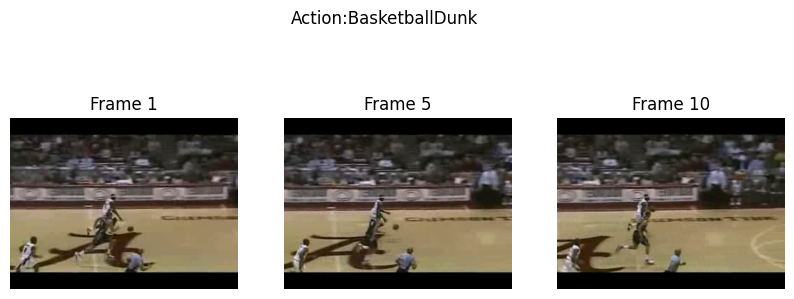

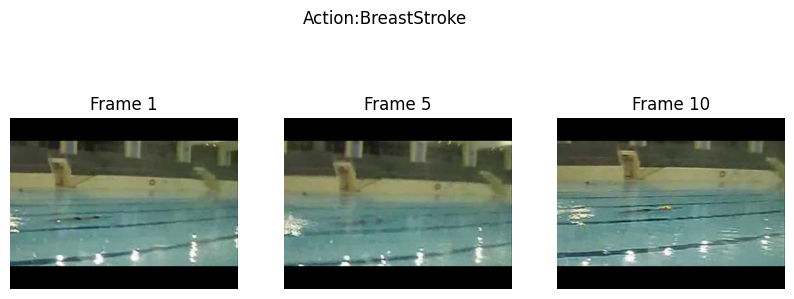

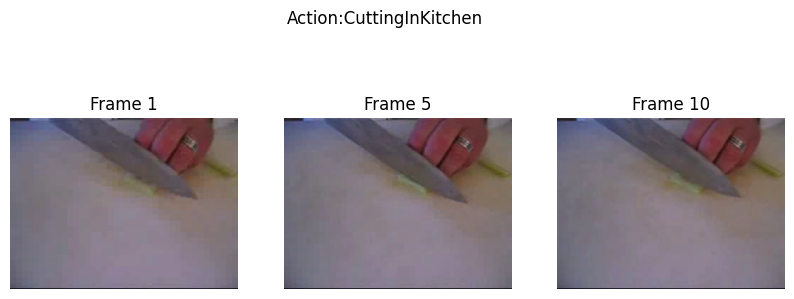

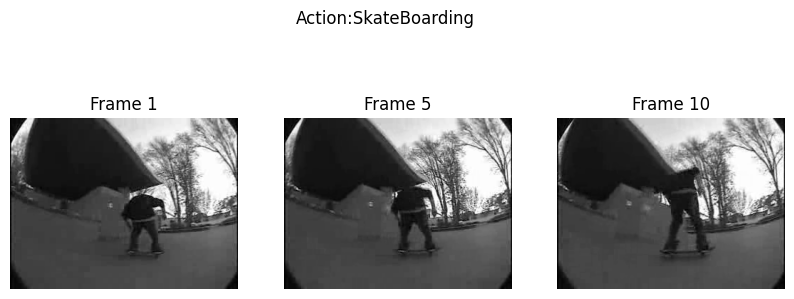

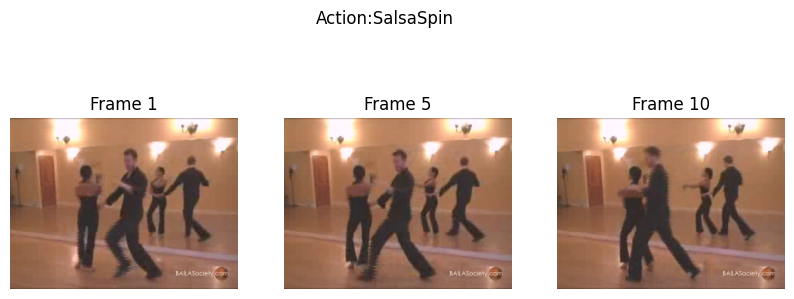

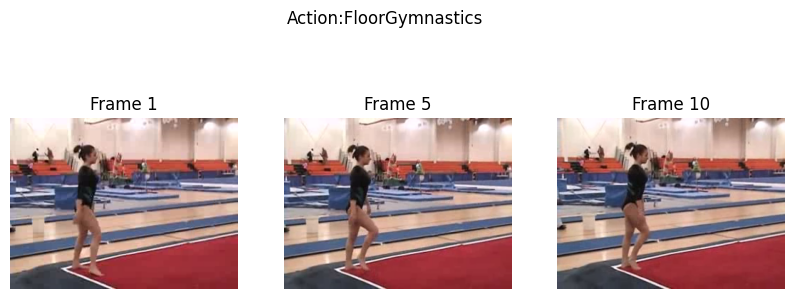

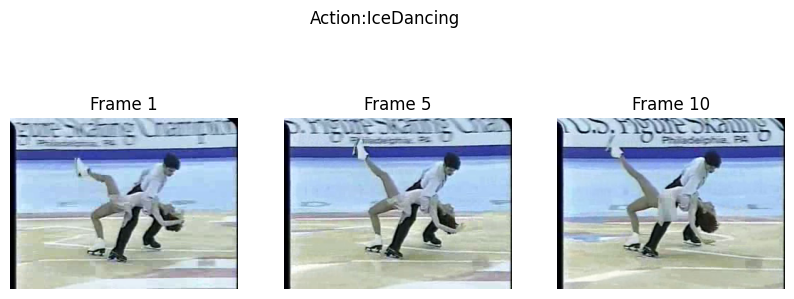

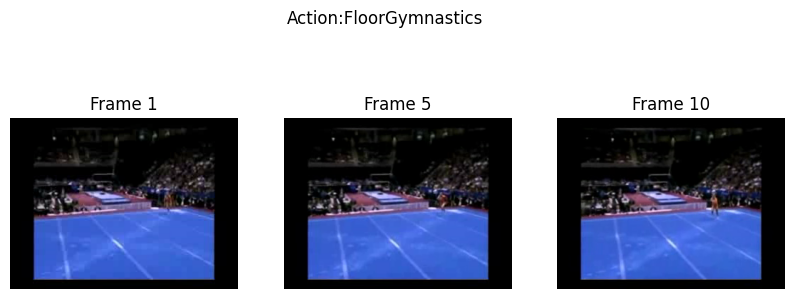

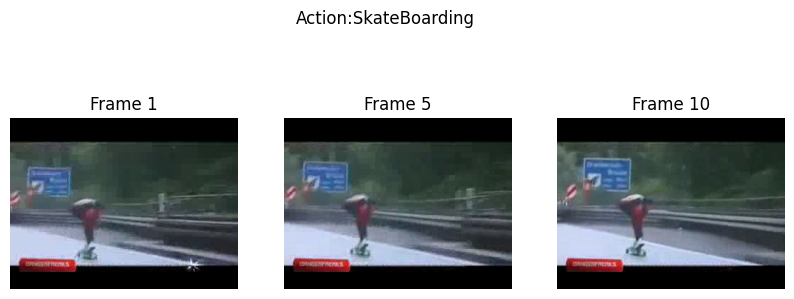

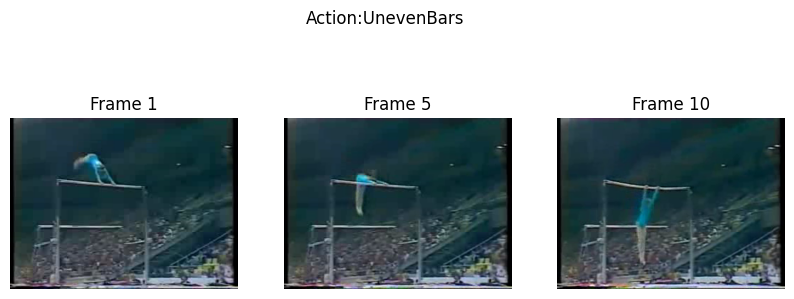

In [ ]:
video_sample_link=train_df_2['clip_path']
frames_to_show=[1,5,10]
for i in idxs:
  full_path=os.path.join(path,video_sample_link[i].lstrip('/'))
  video_reader=cv2.VideoCapture(full_path)
  plt.figure(figsize=(10,4))
  label=train_df_2['label'][i]
  plt.suptitle(f"Action:{label}")

  for j,frame_idx in enumerate(frames_to_show):
    video_reader.set(cv2.CAP_PROP_POS_FRAMES,frame_idx)
    _,bgr_frame=video_reader.read()
    rgb_frame=cv2.cvtColor(bgr_frame,cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(frames_to_show), j+1)
    plt.imshow(rgb_frame)
    plt.title(f"Frame {frame_idx}")
    plt.axis('off')

  plt.show()
  video_reader.release()

In [ ]:
selected_classes

['IceDancing',
 'SalsaSpin',
 'BreastStroke',
 'MilitaryParade',
 'FloorGymnastics',
 'BasketballDunk',
 'UnevenBars',
 'Kayaking',
 'SkateBoarding',
 'CuttingInKitchen']

In [ ]:
train_df_2

,clip_name,clip_path,label
0,v_BreastStroke_g21_c02,/train/BreastStroke/v_BreastStroke_g21_c02.avi,BreastStroke
1,v_BreastStroke_g21_c04,/train/BreastStroke/v_BreastStroke_g21_c04.avi,BreastStroke
2,v_BreastStroke_g22_c02,/train/BreastStroke/v_BreastStroke_g22_c02.avi,BreastStroke
3,v_BreastStroke_g18_c03,/train/BreastStroke/v_BreastStroke_g18_c03.avi,BreastStroke
4,v_BreastStroke_g11_c03,/train/BreastStroke/v_BreastStroke_g11_c03.avi,BreastStroke
...,...,...,...
926,v_SalsaSpin_g04_c01,/train/SalsaSpin/v_SalsaSpin_g04_c01.avi,SalsaSpin
927,v_SalsaSpin_g21_c02,/train/SalsaSpin/v_SalsaSpin_g21_c02.avi,SalsaSpin
928,v_SalsaSpin_g22_c03,/train/SalsaSpin/v_SalsaSpin_g22_c03.avi,SalsaSpin
929,v_SalsaSpin_g05_c02,/train/SalsaSpin/v_SalsaSpin_g05_c02.avi,SalsaSpin


In [ ]:
train_df_2 = train_df_2.sample(frac=1, random_state=42).reset_index(drop=True) #Shuffling the data

In [ ]:
train_df_2

,clip_name,clip_path,label
0,v_BasketballDunk_g15_c06,/train/BasketballDunk/v_BasketballDunk_g15_c06...,BasketballDunk
1,v_BreastStroke_g04_c01,/train/BreastStroke/v_BreastStroke_g04_c01.avi,BreastStroke
2,v_CuttingInKitchen_g24_c02,/train/CuttingInKitchen/v_CuttingInKitchen_g24...,CuttingInKitchen
3,v_SkateBoarding_g10_c04,/train/SkateBoarding/v_SkateBoarding_g10_c04.avi,SkateBoarding
4,v_SalsaSpin_g06_c05,/train/SalsaSpin/v_SalsaSpin_g06_c05.avi,SalsaSpin
...,...,...,...
926,v_FloorGymnastics_g03_c04,/train/FloorGymnastics/v_FloorGymnastics_g03_c...,FloorGymnastics
927,v_Kayaking_g01_c05,/train/Kayaking/v_Kayaking_g01_c05.avi,Kayaking
928,v_SalsaSpin_g20_c01,/train/SalsaSpin/v_SalsaSpin_g20_c01.avi,SalsaSpin
929,v_IceDancing_g07_c03,/train/IceDancing/v_IceDancing_g07_c03.avi,IceDancing


###PRE-PROCESSING

In [ ]:
IMAGE_WIDTH=64
IMAGE_HEIGHT=64
SEQUENCE=15

In [ ]:
def frames_extraction(video_path):
  frames_list=[]
  video_reader=cv2.VideoCapture(video_path)
  video_frames_count=int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
  skip_frames_window=max(int(video_frames_count/SEQUENCE),1)
  for frame_counter in range (SEQUENCE):
    #Set current frame position of the video
    video_reader.set(cv2.CAP_PROP_POS_FRAMES,frame_counter*skip_frames_window)
    success,frame=video_reader.read()
    if not success:
      break
    resized_frame=cv2.resize(frame,(IMAGE_WIDTH,IMAGE_HEIGHT))
    normalized_frame=resized_frame/255
    frames_list.append(normalized_frame)
  video_reader.release()
  return frames_list

In [ ]:
len(train_df_2)

931

In [ ]:
def create_dataset():
  features=[]
  labels=[]
  video_paths=[]
  for i in range (len(train_df_2)):
    video_full_path=os.path.join(path,train_df_2['clip_path'][i].lstrip('/'))
    frames=frames_extraction(video_full_path)
    if len(frames)==SEQUENCE:
      features.append(frames)
      labels.append(train_df_2['label'].iloc[i])
      video_paths.append(video_full_path)
  features=np.asarray(features)
  labels=np.asarray(labels)
  return features,labels,video_paths

In [ ]:
features,labels,video_paths=create_dataset()

In [ ]:
labels

array(['BasketballDunk', 'BreastStroke', 'CuttingInKitchen',
       'SkateBoarding', 'SalsaSpin', 'FloorGymnastics', 'IceDancing',
       'FloorGymnastics', 'SkateBoarding', 'UnevenBars',
       'CuttingInKitchen', 'IceDancing', 'Kayaking', 'IceDancing',
       'Kayaking', 'Kayaking', 'FloorGymnastics', 'IceDancing',
       'IceDancing', 'BasketballDunk', 'MilitaryParade', 'UnevenBars',
       'IceDancing', 'BreastStroke', 'IceDancing', 'UnevenBars',
       'SalsaSpin', 'CuttingInKitchen', 'SalsaSpin', 'Kayaking',
       'IceDancing', 'BreastStroke', 'BreastStroke', 'CuttingInKitchen',
       'MilitaryParade', 'MilitaryParade', 'IceDancing', 'IceDancing',
       'SalsaSpin', 'FloorGymnastics', 'BreastStroke', 'UnevenBars',
       'UnevenBars', 'SkateBoarding', 'SkateBoarding', 'SalsaSpin',
       'SalsaSpin', 'BasketballDunk', 'MilitaryParade', 'UnevenBars',
       'IceDancing', 'UnevenBars', 'FloorGymnastics', 'MilitaryParade',
       'BreastStroke', 'Kayaking', 'Kayaking', 'IceDancin

In [ ]:
unique_labels=sorted(set(labels))
label_to_idx={label_value: i for i, label_value in enumerate(unique_labels)}
labels_encoded = [label_to_idx[label] for label in labels]

In [ ]:
labels_encoded[0:10]

[0, 1, 2, 8, 7, 3, 4, 3, 8, 9]

In [ ]:
features = torch.tensor(features, dtype=torch.float32)
features = features.permute(0,1,4,2,3)

In [ ]:
split = int(0.75 * len(features))
split2=int(0.85*len(features))
features_train,features_val,features_test = features[:split], features[split:split2], features[split2:]
labels_train, labels_val,labels_test = labels_encoded[:split], labels_encoded[split:split2], labels_encoded[split2:]

In [ ]:
len(features_train),len(features_test)

(698, 140)

In [ ]:
len(labels_train),len(labels_test )

(698, 140)

###Building the MODEL CNN+LSTM

In [ ]:
print(features.shape)

torch.Size([931, 15, 3, 64, 64])


In [ ]:
training_loss_lstm=[]
training_acc_lstm=[]
val_loss_lstm=[]
val_acc_lstm=[]

In [ ]:
print(features.shape)

torch.Size([931, 15, 3, 64, 64])


In [ ]:
class CNN_LSTM(nn.Module):
  def __init__(self,num_classes):
    super().__init__()
    resnet=models.resnet18(pretrained=True)
    self.cnn=nn.Sequential(*list(resnet.children())[:-1])
    self.lstm=nn.LSTM(512,216,batch_first=True)
    self.fc=nn.Linear(216,num_classes)

  def forward(self,X):
    B,T,C,H,W=X.shape
    X=X.view(B*T,C,H,W)     #Here we are combining batch and time as we give input as frames
    X=self.cnn(X)
    X=X.view(B,T,512)
    X,_=self.lstm(X)
    X=X[:,-1,:]             #We take last time step coz it contains info of the entire sequence
    X=self.fc(X)
    return X



In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
dataset=TensorDataset(torch.tensor(features_train),torch.tensor(labels_train))
train_loader=DataLoader(dataset,
                        batch_size=8,
                        shuffle=True
                        )

/tmp/ipykernel_410/1950767781.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dataset=TensorDataset(torch.tensor(features_train),torch.tensor(labels_train))


In [ ]:

dataset_val=TensorDataset(torch.tensor(features_val),torch.tensor(labels_val))
val_loader=DataLoader(dataset_val,
                      batch_size=8,
                      shuffle=True
                      )

/tmp/ipykernel_410/4167902606.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dataset_val=TensorDataset(torch.tensor(features_val),torch.tensor(labels_val))


In [ ]:
features=torch.tensor(features)
labels=torch.tensor(labels_encoded)
features=features.permute(0,1,4,2,3)

/tmp/ipykernel_410/3887153462.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  features=torch.tensor(features)


In [ ]:
model=CNN_LSTM(num_classes=10)
optimizer=torch.optim.Adam(model.parameters(),lr=1e-4)
criterion=nn.CrossEntropyLoss()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


In [ ]:
epochs=20
counter=0
patience=3
best_val_loss=float('inf')
model.to(device)
time_lstm=[]
for epoch in range(epochs):
  start_lstm=time.time()
  print(f"Epoch {epoch+1}/{epochs}")
  running_loss=0
  model.train()
  for videos,labels in train_loader:
    videos=videos.to(device)
    labels=labels.to(device)
    output=model(videos)
    loss=criterion(output,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  end_lstm=time.time()
  time_lstm.append(end_lstm-start_lstm)

  model.eval()
  val_loss=0
  correct=0
  total=0
  with torch.no_grad():
    for videos,labels in val_loader:
        videos=videos.to(device)
        labels=labels.to(device)
        output=model(videos)
        loss=criterion(output,labels)
        val_loss+=loss.item()
        pred=torch.argmax(output,dim=1)
        correct+=(pred==labels).sum().item()
        total+=labels.size(0)

    val_loss=val_loss/len(val_loader)
    val_accuracy=correct/total

    if val_loss<best_val_loss:
        best_val_loss=val_loss
        counter=0
        torch.save(model.state_dict(),"best_model.pth")
    else:
        counter+=1
        #if counter>=patience:
          #break

  print(f"Epoch {epoch+1}    Training Loss:{running_loss/len(train_loader)}     |    Val Loss: {val_loss}          |       Val Acc: {val_accuracy}")
  training_loss_lstm.append(running_loss/len(train_loader))
  training_acc_lstm.append(val_accuracy)
  val_loss_lstm.append(val_loss)
  val_acc_lstm.append(val_accuracy)



Epoch 1/20
Epoch 1    Training Loss:1.7599295282905751     |    Val Loss: 0.8915191739797592          |       Val Acc: 0.8924731182795699
Epoch 2/20
Epoch 2    Training Loss:0.5775957285341892     |    Val Loss: 0.29103883417944115          |       Val Acc: 0.9354838709677419
Epoch 3/20
Epoch 3    Training Loss:0.22559894333508881     |    Val Loss: 0.160514198243618          |       Val Acc: 0.978494623655914
Epoch 4/20
Epoch 4    Training Loss:0.17169587123631078     |    Val Loss: 0.10765917521590988          |       Val Acc: 0.978494623655914
Epoch 5/20
Epoch 5    Training Loss:0.11966780319132587     |    Val Loss: 0.10506880438576142          |       Val Acc: 0.978494623655914
Epoch 6/20
Epoch 6    Training Loss:0.12228950712067838     |    Val Loss: 0.10114034389456113          |       Val Acc: 0.978494623655914
Epoch 7/20
Epoch 7    Training Loss:0.08476696922232142     |    Val Loss: 0.10613601716856162          |       Val Acc: 0.978494623655914
Epoch 8/20
Epoch 8    Training

###Self-Attention Architecture.

In [ ]:
class CNN_Attention(nn.Module):
  def __init__(self,num_classes):
    super().__init__()
    resnet=models.resnet18(pretrained=True)
    self.cnn=nn.Sequential(*list(resnet.children())[:-1])
    self.attention=nn.MultiheadAttention(embed_dim=512,num_heads=8,batch_first=True)
    self.fc=nn.Linear(512,num_classes)

  def forward(self,X):
    B,T,C,H,W=X.shape
    X=X.view(B*T,C,H,W)
    X=self.cnn(X)
    X=X.view(B,T,512)
    X,attention_wts=self.attention(X,X,X)   # we pass 3 times X ...query,Key,Value
    X=X.mean(dim=1)             #with this we average all the frames and get a single feature fector for that video....
    X=self.fc(X)
    return X,attention_wts

In [ ]:
model_2=CNN_Attention(num_classes=10)
optimizer=torch.optim.Adam(model_2.parameters(),lr=1e-4)
criterion=nn.CrossEntropyLoss()

In [ ]:
training_loss_attention=[]
training_acc_attention=[]
val_loss_attention=[]
val_acc_attention=[]

In [ ]:
epochs=20
running_loss = 0
val_loss = 0
correct = 0
total = 0
time_attention=[]
model_2.to(device)
for epoch in range(epochs):
  running_loss=0
  val_loss = 0
  correct = 0
  total = 0
  model_2.train()
  start_attention=time.time()
  for videos,labels in train_loader:
    videos=videos.to(device)
    labels=labels.to(device)
    output,_=model_2(videos)
    loss=criterion(output,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  training_loss=running_loss/len(train_loader)
  end_attention=time.time()
  time_attention.append(end_attention-start_attention)

  model_2.eval()
  with torch.no_grad():
    for videos,labels in val_loader:
      videos=videos.to(device)
      labels=labels.to(device)
      output=model_2(videos)
      loss=criterion(output,labels)
      val_loss+=loss.item()
      pred=torch.argmax(output,dim=1)
      correct+=(pred==labels).sum().item()
      total+=labels.size(0)
    val_loss=val_loss/len(val_loader)
    val_accuracy=correct/total

  print(f"Epoch:{epoch+1}     |    Training Loss:{training_loss}       |       Val Loss:{val_loss}           |           Val Acc:{val_accuracy}")
  training_loss_attention.append(training_loss)
  training_acc_attention.append(val_accuracy)
  val_loss_attention.append(val_loss)
  val_acc_attention.append(val_accuracy)


Epoch:1     |    Training Loss:1.1536392390050672       |       Val Loss:0.30898226735492546           |           Val Acc:0.956989247311828
Epoch:2     |    Training Loss:0.32545488665346056       |       Val Loss:0.112478597361284           |           Val Acc:0.967741935483871
Epoch:3     |    Training Loss:0.18946456824514       |       Val Loss:0.10140055427230739           |           Val Acc:0.956989247311828
Epoch:4     |    Training Loss:0.18098137631551997       |       Val Loss:0.12000782007817179           |           Val Acc:0.967741935483871
Epoch:5     |    Training Loss:0.1403370805887376       |       Val Loss:0.10844161198474467           |           Val Acc:0.978494623655914
Epoch:6     |    Training Loss:0.06300418564602626       |       Val Loss:0.2059201824364815           |           Val Acc:0.9354838709677419
Epoch:7     |    Training Loss:0.08440399911209666       |       Val Loss:0.1733121805009432           |           Val Acc:0.946236559139785
Epoch:8     | 

In [ ]:
torch.save(model_2.state_dict(),"CNN_attention.pth")
model_2.to(device)
model_2.eval()

CNN_Attention(
  (cnn): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

In [ ]:
selected_classes

['IceDancing',
 'SalsaSpin',
 'BreastStroke',
 'MilitaryParade',
 'FloorGymnastics',
 'BasketballDunk',
 'UnevenBars',
 'Kayaking',
 'SkateBoarding',
 'CuttingInKitchen']

###PREDICTION

In [ ]:
def predict_action(video_path, SEQUENCE):

    model_2.eval()

    frames = []

    video_reader = cv2.VideoCapture(video_path)

    while video_reader.isOpened():

        ok, frame = video_reader.read()

        if not ok:
            break

        resized_frame = cv2.resize(frame, (IMAGE_WIDTH, IMAGE_HEIGHT))

        normalized_frame = resized_frame / 255.0

        frames.append(normalized_frame)

        if len(frames) == SEQUENCE:
            break

    video_reader.release()

    # Convert to numpy
    frames = np.array(frames)

    # (T,H,W,C) → (1,T,H,W,C)
    frames = np.expand_dims(frames, axis=0)

    # Convert to tensor
    frames = torch.tensor(frames, dtype=torch.float32)

    # (1,T,H,W,C) → (1,T,C,H,W)
    frames = frames.permute(0,1,4,2,3).to(device)

    with torch.no_grad():
        outputs = model_2(frames)

    predicted_class_index = torch.argmax(outputs, dim=1).item()

    predicted_class = unique_labels[predicted_class_index]

    return predicted_class

In [ ]:
file_path=input("Enter video path")
prediction = predict_action(file_path,SEQUENCE)
print(f"Predicted Action: {prediction}")

Enter video path/content/videoplayback (2).mp4
Predicted Action: SkateBoarding


###Analysis

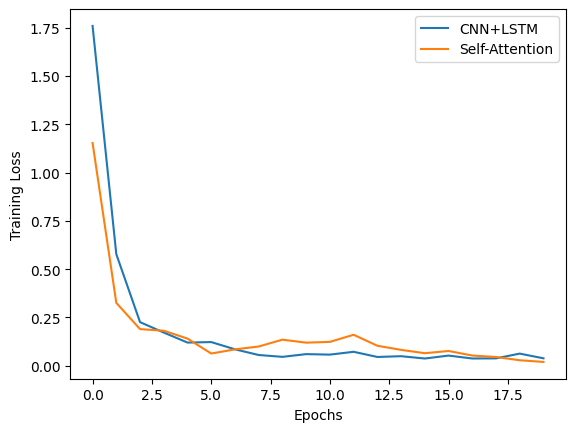

In [ ]:
plt.plot(training_loss_lstm,label="CNN+LSTM")
plt.plot(training_loss_attention,label="Self-Attention")
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.legend()
plt.show()

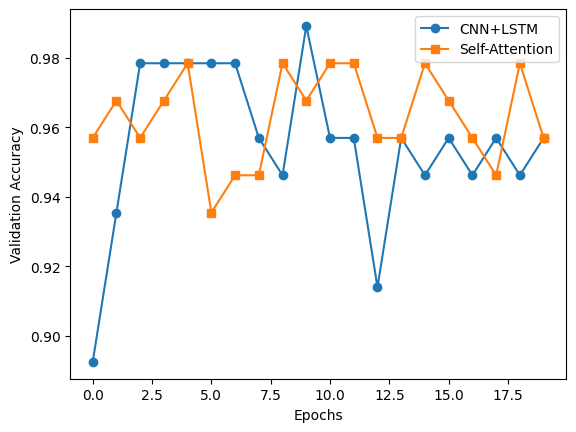

In [ ]:
plt.plot(val_acc_lstm,marker='o',label="CNN+LSTM")
plt.plot(val_acc_attention,marker='s',label="Self-Attention")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

Text(0, 0.5, 'Seconds per Epoch')

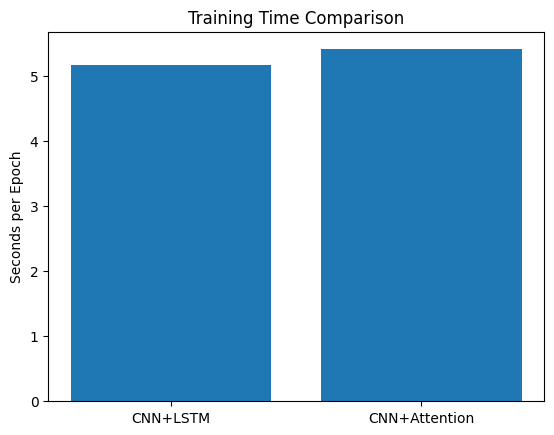

In [ ]:
models = ["CNN+LSTM", "CNN+Attention"]
times = [np.mean(time_lstm), np.mean(time_attention)]

plt.bar(models, times)
plt.title("Training Time Comparison")
plt.ylabel("Seconds per Epoch")

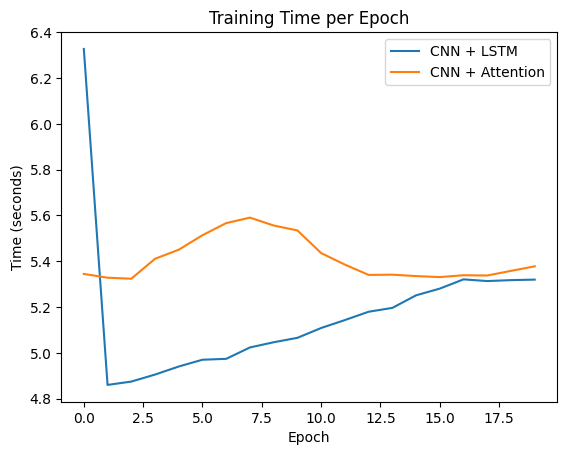

In [ ]:
plt.plot(time_lstm, label="CNN + LSTM")
plt.plot(time_attention, label="CNN + Attention")

plt.xlabel("Epoch")
plt.ylabel("Time (seconds)")
plt.title("Training Time per Epoch")
plt.legend()
plt.show()

In [ ]:
selected_classes

['IceDancing',
 'SalsaSpin',
 'BreastStroke',
 'MilitaryParade',
 'FloorGymnastics',
 'BasketballDunk',
 'UnevenBars',
 'Kayaking',
 'SkateBoarding',
 'CuttingInKitchen']